In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.rcParams.update({
    "font.family":        "serif",
    "font.size":          10,
    "text.color":         "black",
    "axes.titlesize":     11,
    "axes.labelsize":     10,
    "axes.labelcolor":    "black",
    "axes.edgecolor":     "black",
    "xtick.labelsize":    9,
    "xtick.color":        "black",
    "ytick.labelsize":    9,
    "ytick.color":        "black",
    "legend.fontsize":    9,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "black",
    "grid.linestyle":     "--",
    "grid.linewidth":     0.5,
    "grid.alpha":         0.2,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.facecolor":  "white",
})

In [3]:
df = pd.read_csv('frame_latency_20260527_131411.csv')

In [4]:
# pgie_batch_ms=0 제외 후 4채널 배치 처리량 FPS 계산
BATCH_SIZE = int(df['batch_size'].median())
df = df[df['pgie_batch_ms'] > 0].copy()
df['throughput_fps'] = BATCH_SIZE * 1000.0 / df['pgie_batch_ms']

fps = df['throughput_fps']
print(f"batch_size={BATCH_SIZE}  n={len(fps):4d}  mean={fps.mean():.2f}  "
      f"std={fps.std():.2f}  min={fps.min():.2f}  max={fps.max():.2f}  fps")

batch_size=4  n=1443  mean=56.63  std=3.79  min=16.75  max=98.96  fps


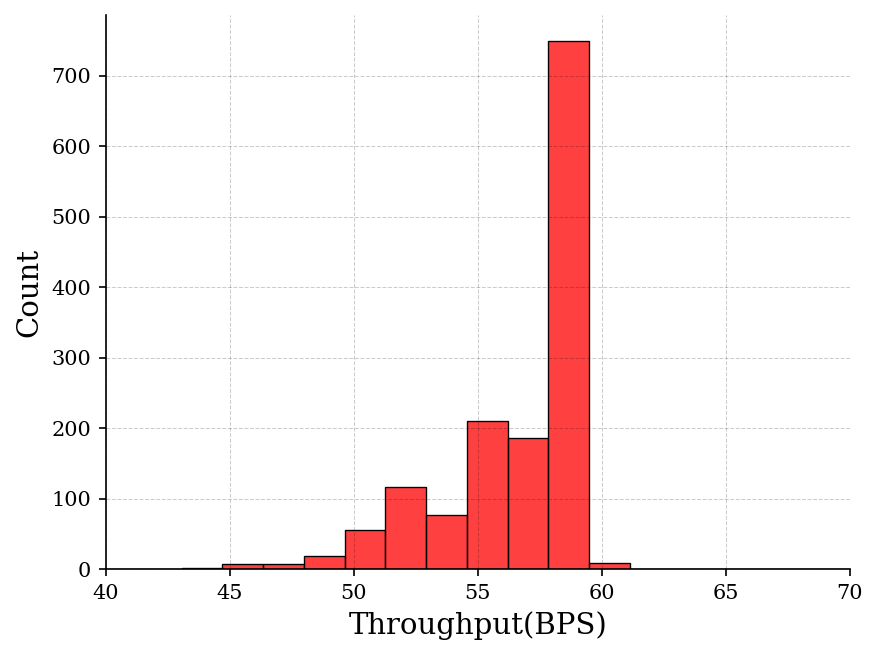

In [7]:
AXIS_FONT_SIZE = 14
TICK_FONT_SIZE = 10

fps = df['throughput_fps']

fig, ax = plt.subplots()
sns.histplot(fps, bins=50, color='red', edgecolor='black', ax=ax)
ax.set_xlabel('Throughput(BPS)', fontsize=AXIS_FONT_SIZE)
ax.set_xlim(40, 70)
ax.set_ylabel('Count', fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)

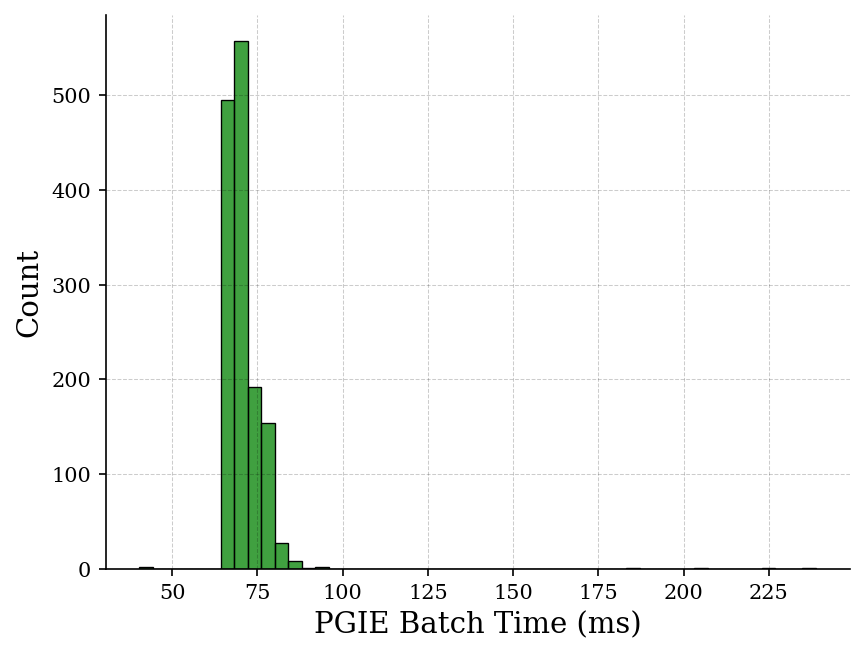

In [6]:
AXIS_FONT_SIZE = 14
TICK_FONT_SIZE = 10

batch_ms = df['pgie_batch_ms']

fig, ax = plt.subplots()
sns.histplot(batch_ms, bins=50, color='green', edgecolor='black', ax=ax)
ax.set_xlabel('PGIE Batch Time (ms)', fontsize=AXIS_FONT_SIZE)
ax.set_ylabel('Count', fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)